<a href="https://colab.research.google.com/github/AyubUmair/Agentic-RAG-System/blob/main/EN3160.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install opencv-python

In [4]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

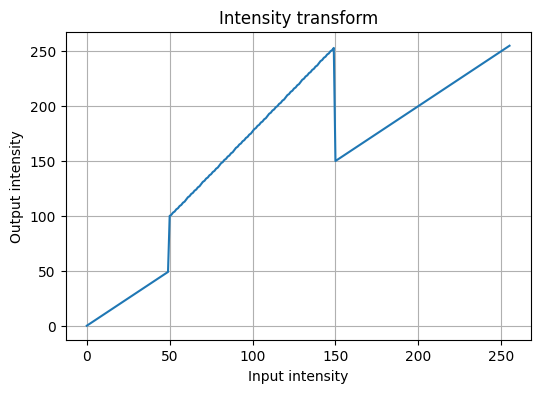

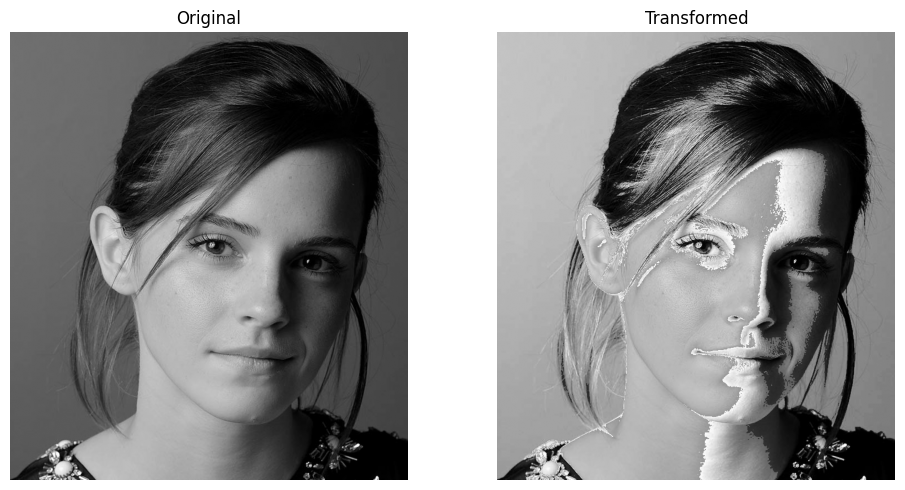

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = cv.imread('emma.jpg', cv.IMREAD_GRAYSCALE)

breakouts = np.array([[0, 0], [50, 50], [50, 100], [150, 255], [150,150],[255, 255]])
x, y = breakouts[:, 0], breakouts[:, 1]

lut = np.interp(np.arange(256), x, y).astype(np.uint8)
output = cv.LUT(image, lut)

plt.figure(figsize=(6, 4))
plt.plot(lut)
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity transform')
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(output, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Transformed')
axes[1].axis('off')

plt.tight_layout()
plt.show()

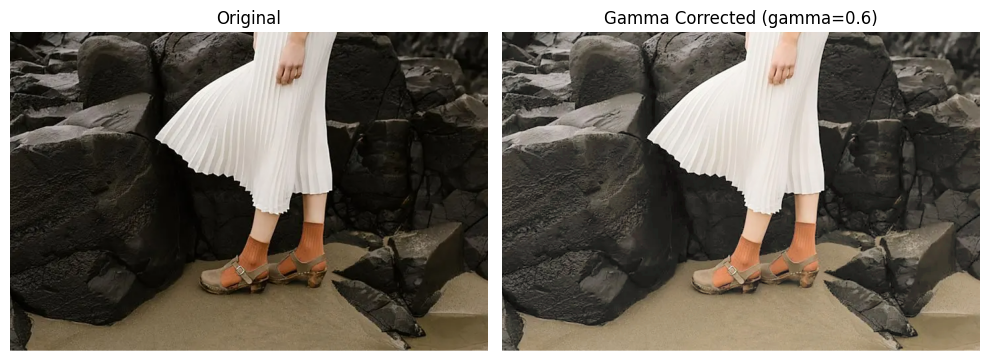

/tmp/ipykernel_4171/3311967125.py:44: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax_hist[0].hist(L.ravel(), 256, [0, 256])
/tmp/ipykernel_4171/3311967125.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax_hist[1].hist(L_corrected.ravel(), 256, [0, 256])


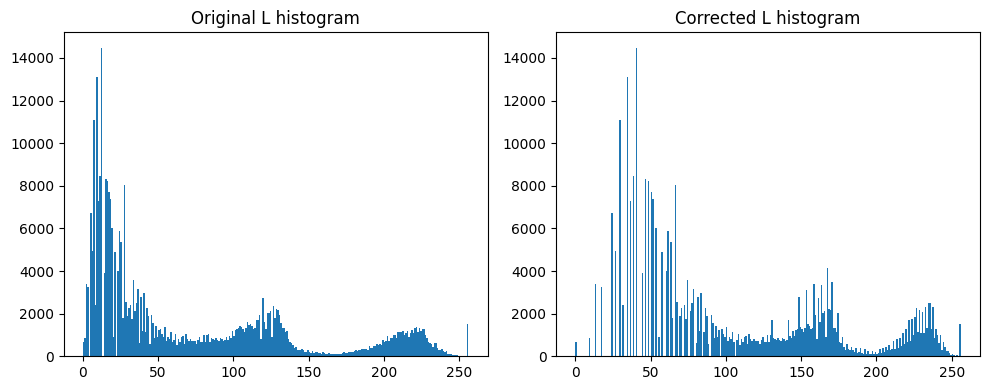

In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = cv.imread('Image for gamma correction.png')

if img is None:
    print("Error: Could not load image. Please check the file name.")
else:

    lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
    L, a, b = cv.split(lab)


    gamma = 0.6   # <1 brightens shadows, >1 darkens/increases contrast
    L_norm = L / 255.0
    L_corrected = np.power(L_norm, gamma) * 255.0
    L_corrected = L_corrected.astype(np.uint8)


    lab_corrected = cv.merge([L_corrected, a, b])
    img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)


    fig_img, ax_img = plt.subplots(1, 2, figsize=(10, 5))


    ax_img[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax_img[0].set_title('Original')
    ax_img[0].axis('off')


    ax_img[1].imshow(cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB))
    ax_img[1].set_title(f'Gamma Corrected (gamma={gamma})')
    ax_img[1].axis('off')

    plt.tight_layout()
    plt.show()

    # --- Display Histograms ---
    fig_hist, ax_hist = plt.subplots(1, 2, figsize=(10, 4))

    ax_hist[0].hist(L.ravel(), 256, [0, 256])
    ax_hist[0].set_title('Original L histogram')

    ax_hist[1].hist(L_corrected.ravel(), 256, [0, 256])
    ax_hist[1].set_title('Corrected L histogram')

    plt.tight_layout()
    plt.show()